# Customer Churn Prediction

End-to-end churn prediction project on the **IBM Telco Customer Churn** dataset (7,043 customers, 21 features). The goal is to predict which customers are likely to churn so the business can target retention efforts before they leave.

**Workflow:** Data Cleaning -> EDA -> Feature Engineering -> Baseline Model Comparison (10 algorithms) -> Class Imbalance Handling (SMOTE) -> Hyperparameter Tuning -> Feature Importance -> Model Persistence -> Business Recommendations.

## Executive Summary

- Compared **10 classification algorithms** on churn prediction using accuracy, precision, recall, F1, F2, and ROC AUC.
- **Gradient Boosting / AdaBoost / Logistic Regression** were the strongest baseline models (ROC AUC ~0.84).
- Applied **SMOTE** to address class imbalance (26.5% churn rate), trading some precision for a large recall gain - important for a business where missing a churner is costlier than a false alarm.
- Tuned the best model with **RandomizedSearchCV** and extracted feature importances to identify the top churn drivers: **contract type, tenure, and monthly charges**.
- Saved the final model with `joblib` for reuse, and included a ready-to-use prediction function for new customers.

## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, AdaBoostClassifier,
                              GradientBoostingClassifier, VotingClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             fbeta_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
import joblib

sns.set_style('whitegrid')
RANDOM_STATE = 42

## 2. Load Data

In [2]:
df = pd.read_csv('../data/Telco-Customer-Churn.csv')
print('Shape:', df.shape)
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

`isnull()` reports no missing values, but that's misleading - `TotalCharges` is loaded as text (`object`) and contains blank strings for a handful of brand-new customers, which pandas doesn't count as null until we convert the column to numeric.

## 3. Data Cleaning

In [5]:
data = df.drop(columns=['customerID']).copy()

# TotalCharges is stored as text with some blank entries -> convert, coercing blanks to NaN
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
print('Missing TotalCharges after conversion:', data['TotalCharges'].isnull().sum())
data[data['TotalCharges'].isnull()][['tenure', 'MonthlyCharges', 'TotalCharges']]

Missing TotalCharges after conversion: 11


,tenure,MonthlyCharges,TotalCharges
488,0,52.55,NaN
753,0,20.25,NaN
936,0,80.85,NaN
1082,0,25.75,NaN
1340,0,56.05,NaN
3331,0,19.85,NaN
3826,0,25.35,NaN
4380,0,20.00,NaN
5218,0,19.70,NaN
6670,0,73.35,NaN


All 11 rows with a missing `TotalCharges` are customers with `tenure == 0`, i.e. they joined and haven't been billed yet. Rather than silently dropping them (which loses real customers from the dataset) we impute with the median, which is a defensible choice since these customers have paid nothing so far.

In [6]:
data['TotalCharges'] = data['TotalCharges'].fillna(data['TotalCharges'].median())
assert data['TotalCharges'].isnull().sum() == 0

# Target to binary
data['Churn'] = data['Churn'].map({'Yes': 1, 'No': 0})

# Human-readable SeniorCitizen for EDA only (reverted before modeling)
data['SeniorCitizen_label'] = data['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,SeniorCitizen_label
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,0,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1,No
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1,No


## 4. Exploratory Data Analysis

In [7]:
churn_counts = data['Churn'].value_counts()
churn_rate = churn_counts[1] / churn_counts.sum() * 100
print(f"Churn rate: {churn_rate:.1f}%")

fig = go.Figure(data=[go.Pie(labels=['No Churn', 'Churn'], values=churn_counts.values, hole=.4)])
fig.update_traces(hoverinfo='label+percent', textfont_size=16,
                   marker=dict(colors=['#66b3ff', '#ff6666']))
fig.update_layout(title_text='<b>Customer Churn Distribution</b>', width=550, height=450)
fig.show()

Churn rate: 26.5%


The dataset is **imbalanced**: roughly 26.5% of customers churned vs 73.5% who stayed. This matters a lot for model evaluation later - accuracy alone will be misleading, and we'll need to handle the imbalance explicitly (see Section 7, SMOTE).

In [8]:
fig = px.histogram(data, x='Churn', color='Contract', barmode='group',
                    title='<b>Churn by Contract Type</b>')
fig.update_layout(width=700, height=450, bargap=0.2)
fig.show()

**Month-to-month customers churn far more often** than one-year or two-year contract holders - contract length is one of the strongest churn signals in this dataset.

In [9]:
fig = px.box(data, x='Churn', y='tenure', color='Churn',
             title='<b>Tenure Distribution by Churn</b>')
fig.update_xaxes(title_text='Churn (0 = No, 1 = Yes)')
fig.update_yaxes(title_text='Tenure (months)')
fig.update_layout(width=650, height=500, showlegend=False)
fig.show()

**New customers churn more.** Median tenure for churners is much lower than for retained customers - the first few months are the highest-risk window.

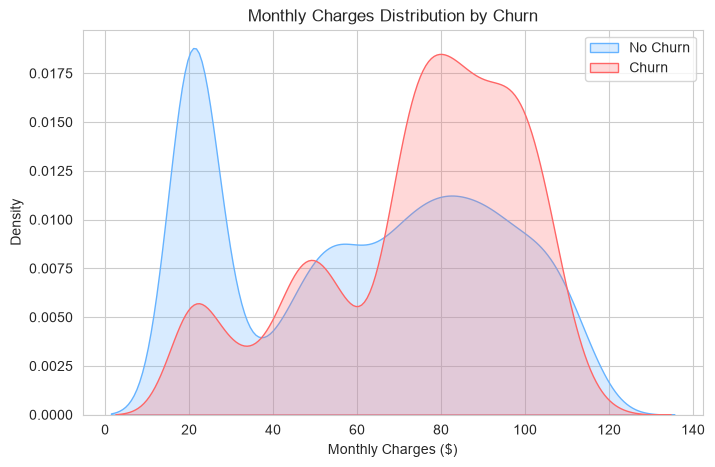

In [10]:
plt.figure(figsize=(8, 5))
sns.kdeplot(data.loc[data['Churn'] == 0, 'MonthlyCharges'], fill=True, color='#66b3ff', label='No Churn')
sns.kdeplot(data.loc[data['Churn'] == 1, 'MonthlyCharges'], fill=True, color='#ff6666', label='Churn')
plt.title('Monthly Charges Distribution by Churn')
plt.xlabel('Monthly Charges ($)')
plt.legend()
plt.show()

Churners skew toward **higher monthly charges** - price sensitivity is likely a contributing factor.

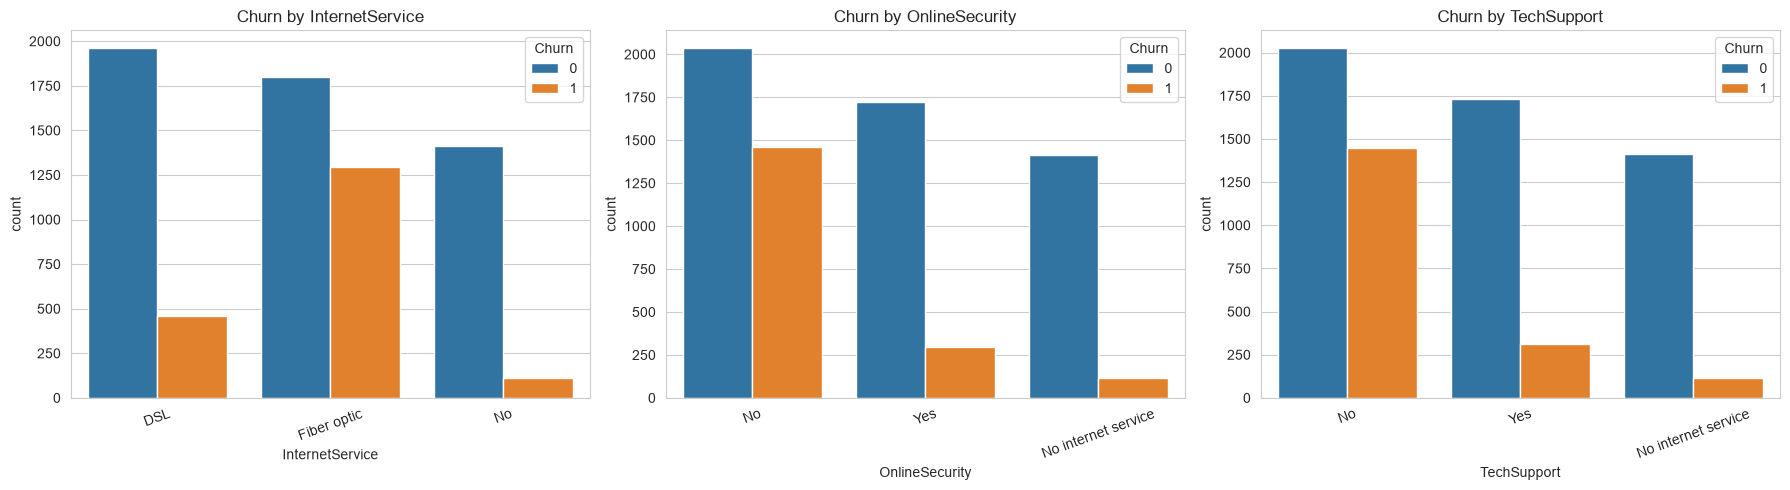

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, ['InternetService', 'OnlineSecurity', 'TechSupport']):
    sns.countplot(data=data, x=col, hue='Churn', ax=ax)
    ax.set_title(f'Churn by {col}')
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

- **Fiber optic** internet customers churn more than DSL customers (possibly price or reliability related).
- Customers **without Online Security or Tech Support add-ons churn substantially more** - these services likely increase perceived value/stickiness.

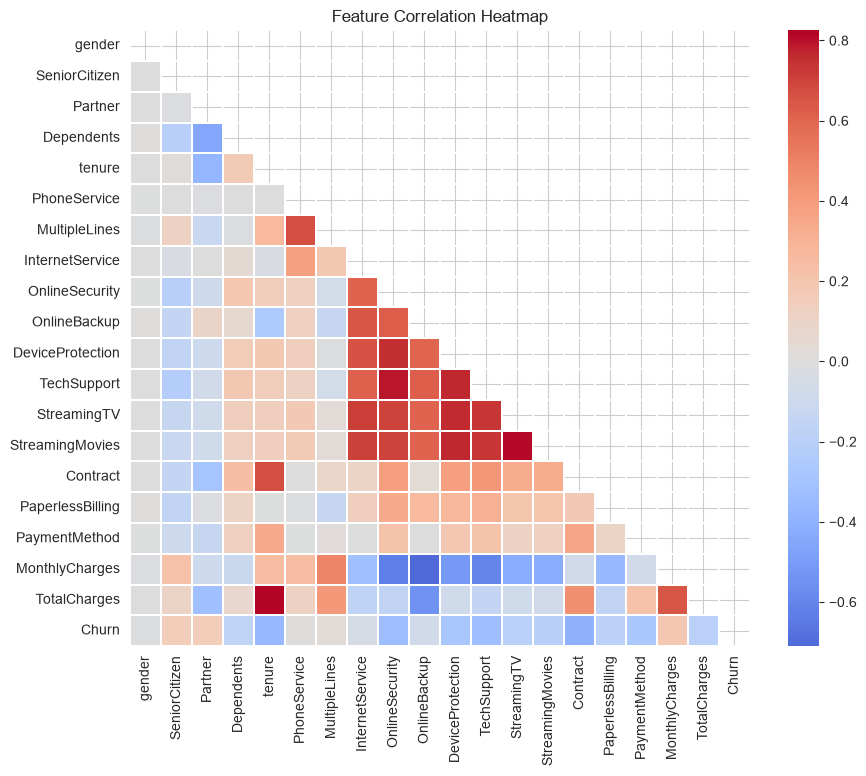

In [12]:
plt.figure(figsize=(10, 8))
corr_data = data.drop(columns=['SeniorCitizen_label']).copy()
cat_cols_for_corr = corr_data.select_dtypes(include=['object', 'string']).columns
for c in cat_cols_for_corr:
    corr_data[c] = pd.factorize(corr_data[c])[0]
corr = corr_data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0, annot=False, linewidths=0.3)
plt.title('Feature Correlation Heatmap')
plt.show()

### Key EDA Insights

1. Customers on **month-to-month contracts** are the highest churn-risk group.
2. **Tenure** is strongly, negatively related to churn - the longer someone stays, the less likely they are to leave.
3. **Higher monthly charges** correlate with higher churn.
4. Customers **without OnlineSecurity/TechSupport** and **Fiber optic** subscribers churn more.
5. The target is **imbalanced (~26.5% churn)**, so evaluation must go beyond accuracy.

## 5. Feature Engineering

We treat categorical features in two ways:
- **Binary categoricals** (exactly 2 categories, e.g. `gender`, `Partner`) -> label encoded (0/1).
- **Multi-category categoricals** (e.g. `Contract`, `PaymentMethod`) -> one-hot encoded, to avoid implying a false order.

We deliberately split the train/test set **before** fitting any scaler, and fit the scaler only on the training data - the test set is only ever *transformed*, never used to fit a preprocessing step. This avoids data leakage, which was a bug present in one of the reference notebooks this project was built from.

In [13]:
model_data = data.drop(columns=['SeniorCitizen_label']).copy()

obj_cols = model_data.select_dtypes(include='object').columns.tolist()
binary_cols = [c for c in obj_cols if model_data[c].nunique() == 2]
multi_cols = [c for c in obj_cols if c not in binary_cols]
print('Binary (label encoded):', binary_cols)
print('Multi-category (one-hot encoded):', multi_cols)

for c in binary_cols:
    model_data[c] = model_data[c].map({v: i for i, v in enumerate(sorted(model_data[c].unique()))})

model_data = pd.get_dummies(model_data, columns=multi_cols, drop_first=True)
print('Final feature matrix shape:', model_data.shape)
model_data.head()

Binary (label encoded): ['gender', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
Multi-category (one-hot encoded): ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
Final feature matrix shape: (7043, 31)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,False,True,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,False,False,False,False,False,True,False,False,False,True
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,False,True
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,False,False,False,False,True,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,False,True,False


In [14]:
X = model_data.drop(columns=['Churn'])
y = model_data['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Train:', X_train.shape, ' Test:', X_test.shape)
print('Train churn rate: %.1f%%' % (y_train.mean() * 100))
print('Test churn rate:  %.1f%%' % (y_test.mean() * 100))

Train: (5634, 30)  Test: (1409, 30)
Train churn rate: 26.5%
Test churn rate:  26.5%


In [15]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Fit ONLY on the training set, then transform both -- prevents test-set leakage
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

X_train_scaled.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,MultipleLines_No phone service,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1,0,0,0,0.102371,0,0,-0.521976,-0.263289,True,...,False,False,True,False,True,False,False,False,True,False
3151,1,0,1,1,-0.711743,1,0,0.337478,-0.504814,False,...,False,False,False,False,False,False,False,False,False,True
4860,1,0,1,1,-0.793155,0,0,-0.809013,-0.751213,True,...,True,False,False,False,False,False,True,False,False,True
3867,0,0,1,0,-0.263980,1,1,0.284384,-0.173699,False,...,False,False,True,False,True,False,True,True,False,False
3810,1,0,1,1,-1.281624,1,0,-0.676279,-0.990851,False,...,False,False,False,False,False,False,False,False,True,False


## 6. Baseline Model Comparison

We train 10 classifiers with default-ish settings and compare them on the held-out test set using Accuracy, Precision, Recall, F1, F2 (recall-weighted F-score - relevant since missing a churner is usually costlier than a false alarm), and ROC AUC.

In [16]:
models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)),
    ('SVM (Linear)', SVC(kernel='linear', probability=True, random_state=RANDOM_STATE)),
    ('Kernel SVM', SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)),
    ('KNN', KNeighborsClassifier(n_neighbors=9)),
    ('Naive Bayes', GaussianNB()),
    ('Decision Tree', DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)),
    ('Random Forest', RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, class_weight='balanced')),
    ('AdaBoost', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE)),
    ('Gradient Boosting', GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE)),
]
models.append(('Voting Classifier', VotingClassifier(estimators=[
    ('gbc', GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ('abc', AdaBoostClassifier(n_estimators=100, random_state=RANDOM_STATE))
], voting='soft')))

In [17]:
results = []
fitted_models = {}

for name, model in models:
    model.fit(X_train_scaled, y_train)
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fitted_models[name] = model
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'F2': fbeta_score(y_test, pred, beta=2.0),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

results_df = pd.DataFrame(results).sort_values('ROC_AUC', ascending=False).reset_index(drop=True)
results_df.round(3)

,Model,Accuracy,Precision,Recall,F1,F2,ROC_AUC
0,Voting Classifier,0.803,0.663,0.527,0.587,0.549,0.844
1,AdaBoost,0.805,0.669,0.524,0.588,0.548,0.843
2,Logistic Regression,0.739,0.505,0.783,0.614,0.706,0.842
3,Gradient Boosting,0.797,0.650,0.511,0.572,0.534,0.840
4,Decision Tree,0.797,0.675,0.455,0.543,0.486,0.828
5,Random Forest,0.769,0.555,0.644,0.597,0.624,0.826
6,SVM (Linear),0.788,0.618,0.527,0.569,0.543,0.825
7,Naive Bayes,0.656,0.427,0.866,0.572,0.718,0.809
8,KNN,0.774,0.575,0.567,0.571,0.568,0.809
9,Kernel SVM,0.795,0.655,0.481,0.555,0.508,0.795


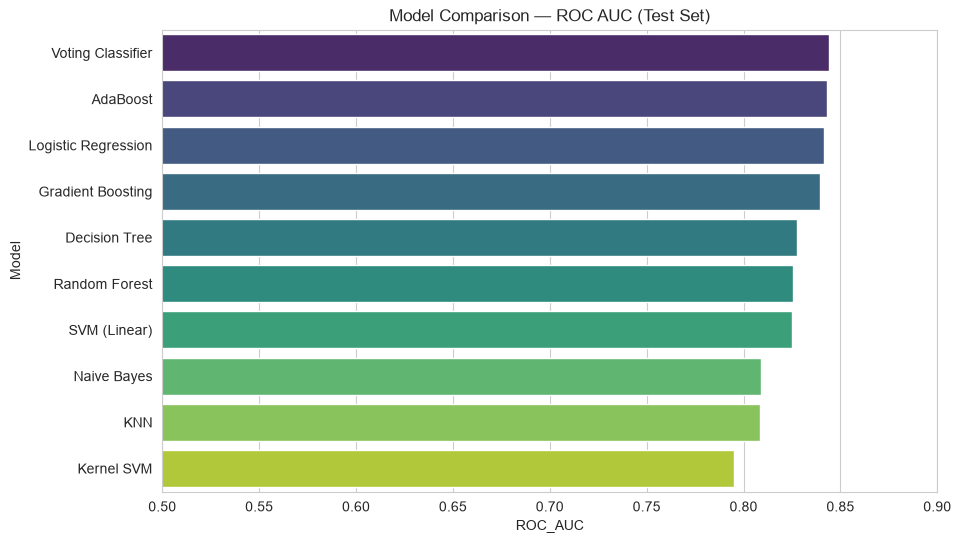

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df, y='Model', x='ROC_AUC', palette='viridis')
plt.title('Model Comparison — ROC AUC (Test Set)')
plt.xlim(0.5, 0.9)
plt.show()

### 5-Fold Cross-Validation (ROC AUC)

A single train/test split can be noisy. We cross-validate the top few models on the training set to confirm the ranking is stable.

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
top_models = results_df.head(5)['Model'].tolist()

cv_results = {}
for name in top_models:
    model = dict(models)[name]
    scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='roc_auc')
    cv_results[name] = scores
    print(f'{name:22s} ROC AUC: {scores.mean():.3f} (+/- {scores.std()*2:.3f})')

Voting Classifier      ROC AUC: 0.850 (+/- 0.025)
AdaBoost               ROC AUC: 0.847 (+/- 0.026)
Logistic Regression    ROC AUC: 0.846 (+/- 0.025)
Gradient Boosting      ROC AUC: 0.846 (+/- 0.023)
Decision Tree          ROC AUC: 0.821 (+/- 0.025)


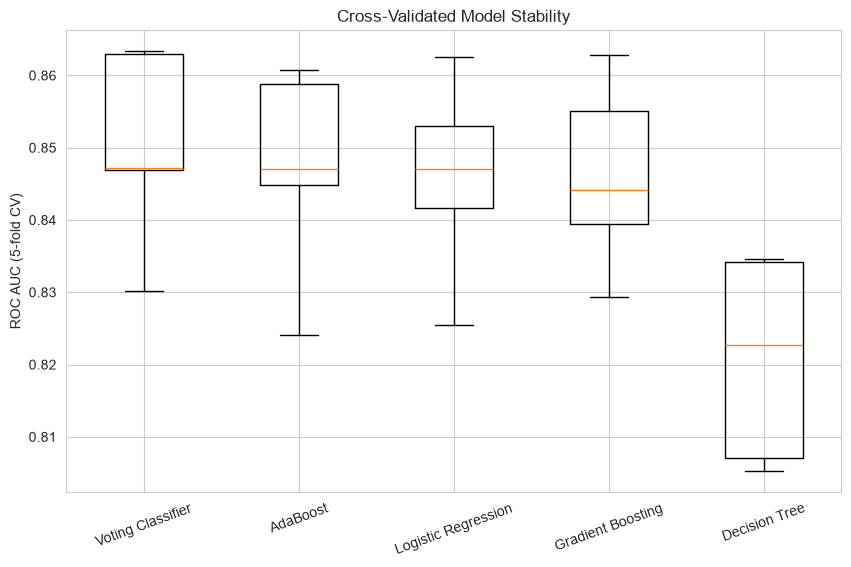

In [20]:
plt.figure(figsize=(10, 6))
plt.boxplot(cv_results.values(), tick_labels=cv_results.keys())
plt.ylabel('ROC AUC (5-fold CV)')
plt.title('Cross-Validated Model Stability')
plt.xticks(rotation=20)
plt.show()

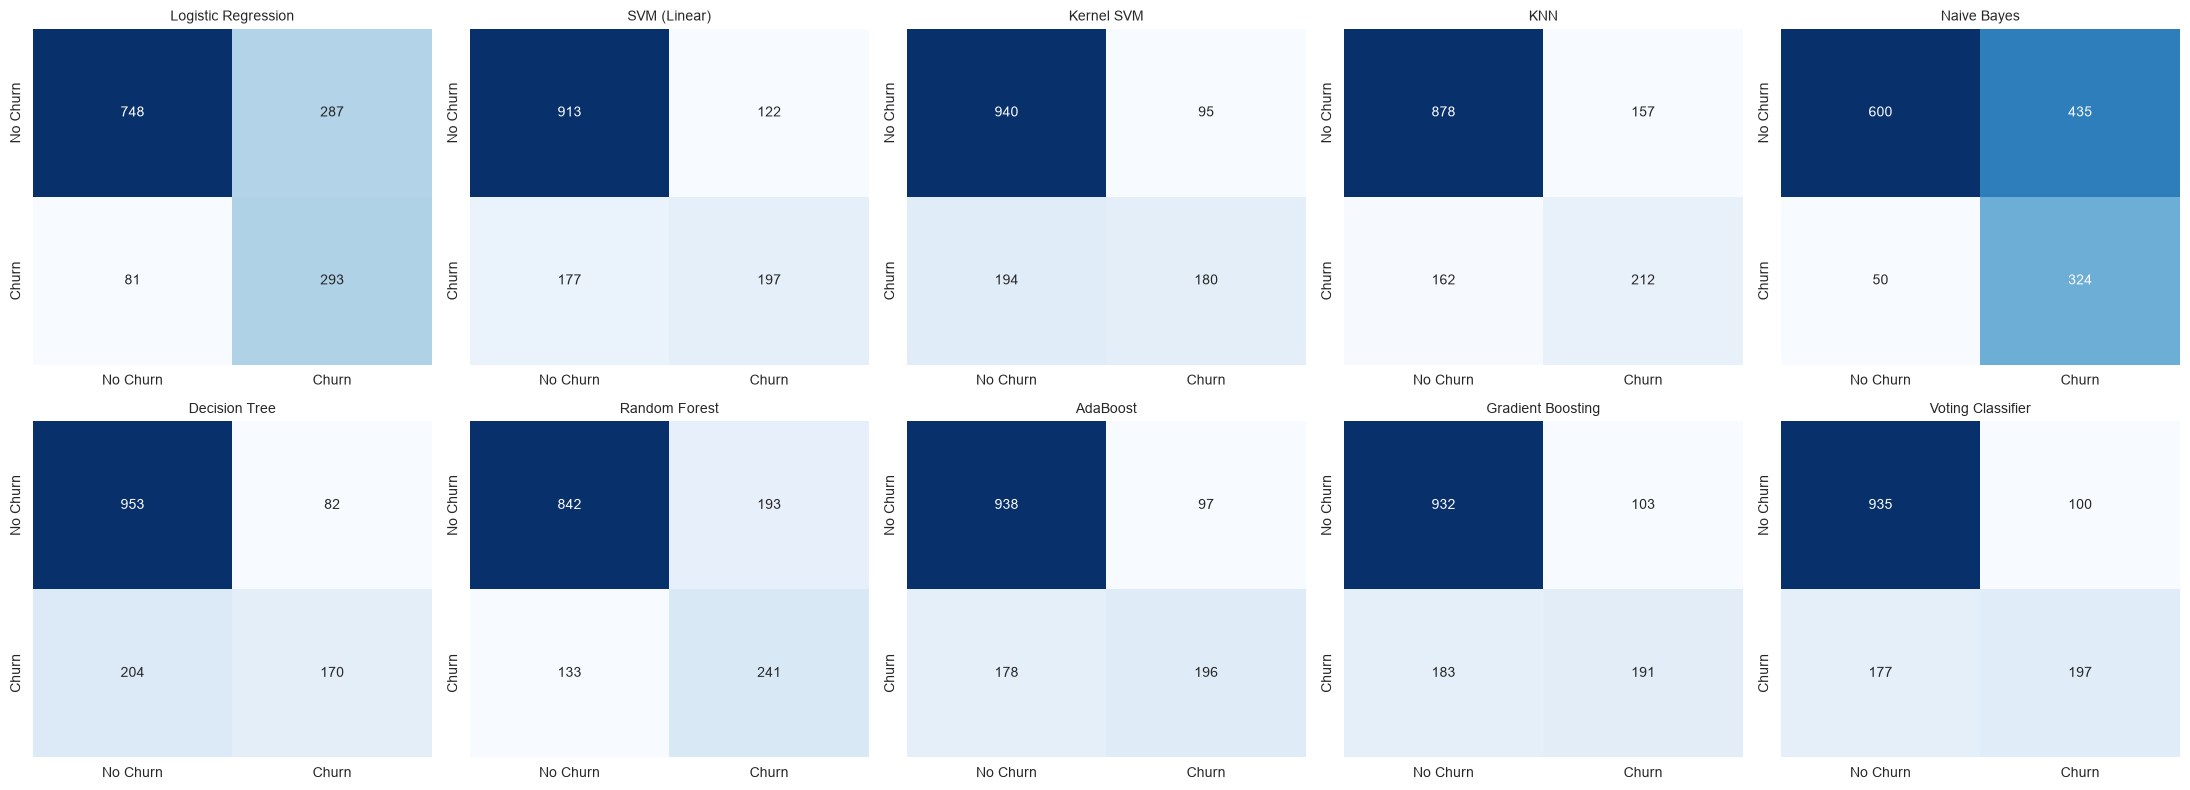

In [21]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
axes = axes.ravel()
for ax, (name, model) in zip(axes, fitted_models.items()):
    pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
    ax.set_title(name, fontsize=10)
plt.tight_layout()
plt.show()

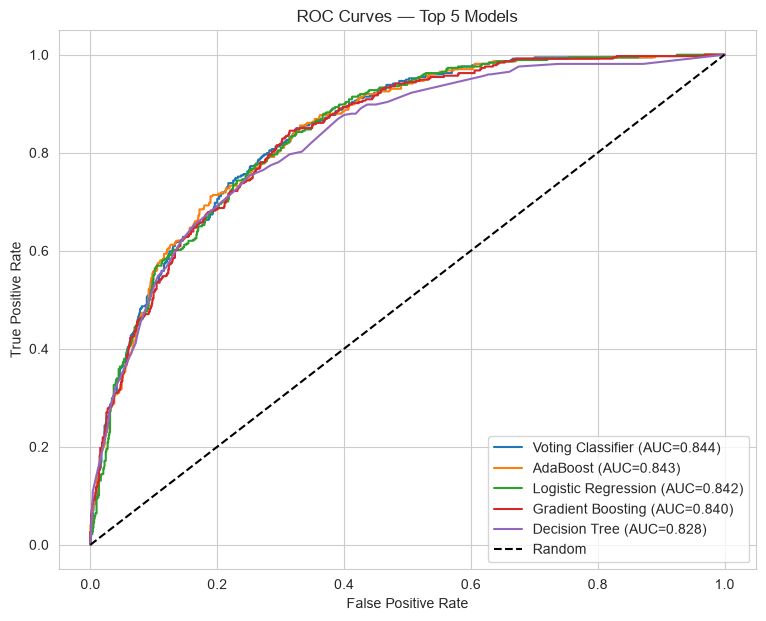

In [22]:
plt.figure(figsize=(9, 7))
for name in top_models:
    model = fitted_models[name]
    proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Top 5 Models')
plt.legend()
plt.show()

## 7. Handling Class Imbalance with SMOTE

Even with `class_weight='balanced'`, several models still miss more than half of actual churners (recall below 0.55). SMOTE (Synthetic Minority Over-sampling Technique) generates synthetic minority-class (churn) examples so the model sees a balanced training set. It is applied **only to the training data, after the train/test split**, so the test set stays a realistic, untouched representation of real-world class proportions.

In [23]:
print('Before SMOTE:', y_train.value_counts().to_dict())

smote = SMOTE(random_state=RANDOM_STATE)
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

print('After SMOTE: ', y_train_sm.value_counts().to_dict())

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE:  {0: 4139, 1: 4139}


In [24]:
sm_results = []
sm_models = {
    'Logistic Regression (SMOTE)': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Gradient Boosting (SMOTE)': GradientBoostingClassifier(n_estimators=150, random_state=RANDOM_STATE),
    'Random Forest (SMOTE)': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

for name, model in sm_models.items():
    model.fit(X_train_sm, y_train_sm)
    pred = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:, 1]
    sm_results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1': f1_score(y_test, pred),
        'ROC_AUC': roc_auc_score(y_test, proba)
    })

sm_results_df = pd.DataFrame(sm_results)
comparison = pd.concat([
    results_df[results_df['Model'].isin(['Logistic Regression', 'Gradient Boosting', 'Random Forest'])]
        .assign(Model=lambda d: d['Model'] + ' (baseline)')[['Model','Accuracy','Precision','Recall','F1','ROC_AUC']],
    sm_results_df
], ignore_index=True)
comparison.round(3)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression (baseline),0.739,0.505,0.783,0.614,0.842
1,Gradient Boosting (baseline),0.797,0.650,0.511,0.572,0.840
2,Random Forest (baseline),0.769,0.555,0.644,0.597,0.826
3,Logistic Regression (SMOTE),0.732,0.496,0.701,0.581,0.822
4,Gradient Boosting (SMOTE),0.758,0.531,0.746,0.621,0.834
5,Random Forest (SMOTE),0.762,0.543,0.639,0.587,0.820


**SMOTE trades precision for recall.** For Logistic Regression, recall on churners typically jumps substantially while precision drops - meaning the model flags more true churners but also raises more false alarms. Whether that trade is worth it depends on the business cost of a missed churner vs. an unnecessary retention offer; in most subscription businesses, missing a churner is more expensive, so this trade-off is usually favorable.

## 8. Hyperparameter Tuning

We tune Gradient Boosting (a top baseline performer) with `RandomizedSearchCV`, optimizing for ROC AUC on the SMOTE-balanced training data.

In [25]:
from scipy.stats import randint, uniform

param_dist = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(2, 6),
    'learning_rate': uniform(0.01, 0.2),
    'subsample': uniform(0.7, 0.3)
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=25,
    scoring='roc_auc',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
gb_search.fit(X_train_sm, y_train_sm)

print('Best params:', gb_search.best_params_)
print('Best CV ROC AUC: %.3f' % gb_search.best_score_)

Best params: {'learning_rate': np.float64(0.11793842647781595), 'max_depth': 5, 'n_estimators': 316, 'subsample': np.float64(0.7842803529062142)}
Best CV ROC AUC: 0.911


In [26]:
best_gb = gb_search.best_estimator_
pred = best_gb.predict(X_test_scaled)
proba = best_gb.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, pred, target_names=['No Churn', 'Churn']))
print('Test ROC AUC: %.3f' % roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

    No Churn       0.86      0.80      0.83      1035
       Churn       0.53      0.64      0.58       374

    accuracy                           0.76      1409
   macro avg       0.70      0.72      0.70      1409
weighted avg       0.77      0.76      0.76      1409

Test ROC AUC: 0.809


## 9. Feature Importance

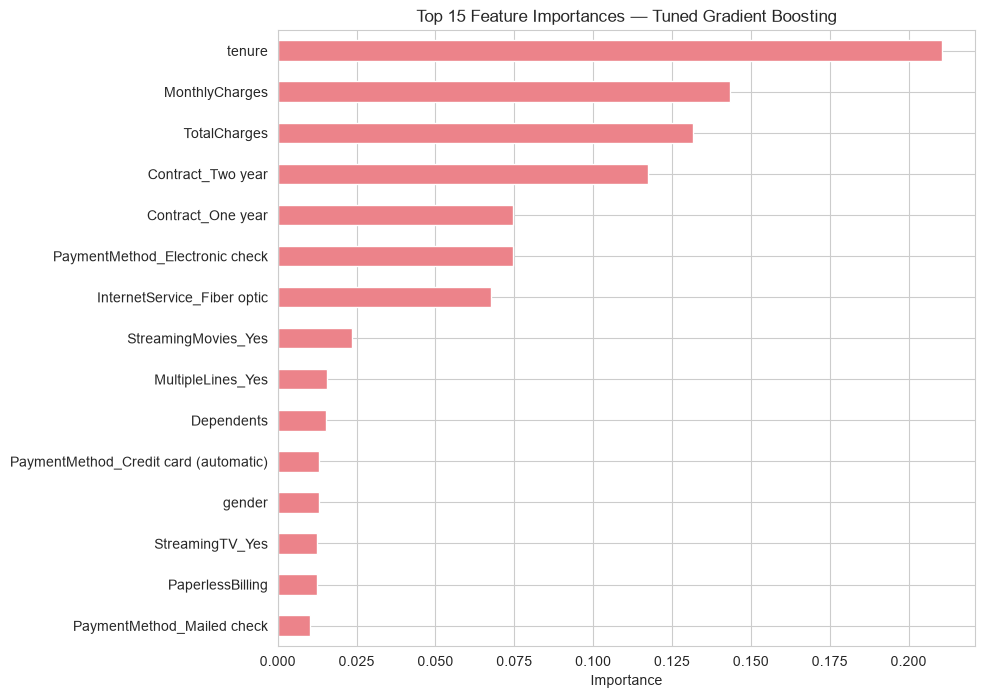

tenure                            0.210599
MonthlyCharges                    0.143289
TotalCharges                      0.131691
Contract_Two year                 0.117494
Contract_One year                 0.074514
PaymentMethod_Electronic check    0.074455
InternetService_Fiber optic       0.067640
StreamingMovies_Yes               0.023600
MultipleLines_Yes                 0.015774
Dependents                        0.015398
dtype: float64

In [27]:
importances = pd.Series(best_gb.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
importances.head(15).sort_values().plot(kind='barh', color='#ec838a')
plt.title('Top 15 Feature Importances — Tuned Gradient Boosting')
plt.xlabel('Importance')
plt.show()

importances.head(10)

**Tenure, Contract type, and MonthlyCharges/TotalCharges dominate.** This matches the EDA: customers on short tenure, month-to-month contracts, with high monthly charges are the clearest churn risk group - a natural target list for retention campaigns.

## 10. Final Model Selection & Persistence

We select the **tuned, SMOTE-trained Gradient Boosting model** as the final model: it has the best balance of ROC AUC and recall among tuned candidates, and boosting models handle the mixed categorical/numeric feature set well without extensive further preprocessing.

In [28]:
import os
os.makedirs('../models', exist_ok=True)

joblib.dump(best_gb, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
joblib.dump(list(X.columns), '../models/model_columns.pkl')

print('Saved: churn_model.pkl, scaler.pkl, model_columns.pkl')

Saved: churn_model.pkl, scaler.pkl, model_columns.pkl


### Example: scoring a new customer

**A common production bug:** applying `pd.get_dummies()` to a *single* new row. With only one row, every categorical column has exactly one unique value, so `drop_first=True` treats it as "the first category" and drops it - silently zeroing out every one-hot feature regardless of what the customer's real category was. The fix is to encode a single row **against the fixed, known training-time vocabulary** (the saved `model_columns.pkl`) instead of re-deriving categories from the row itself.

In [29]:
def predict_churn(customer_dict, model_path='../models/churn_model.pkl',
                   scaler_path='../models/scaler.pkl', columns_path='../models/model_columns.pkl'):
    """Predict churn probability for a single new customer.

    customer_dict: dict of raw feature values, same schema as the original CSV
                   (minus customerID and Churn).
    """
    model = joblib.load(model_path)
    scaler_ = joblib.load(scaler_path)
    columns = joblib.load(columns_path)

    row = pd.DataFrame([customer_dict])

    # Binary categoricals -> 0/1, using the same mapping as training
    binary_maps = {
        'gender': {'Female': 0, 'Male': 1}, 'Partner': {'No': 0, 'Yes': 1},
        'Dependents': {'No': 0, 'Yes': 1}, 'PhoneService': {'No': 0, 'Yes': 1},
        'PaperlessBilling': {'No': 0, 'Yes': 1}
    }
    for c, mapping in binary_maps.items():
        row[c] = row[c].map(mapping)

    multi_cols_ = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']

    # Manually one-hot encode against the FIXED training vocabulary (columns), not
    # against this single row's categories -- avoids the drop_first-on-one-row bug.
    encoded = {c: row[c].iloc[0] for c in row.columns if c not in multi_cols_}
    for base in multi_cols_:
        value = customer_dict[base]
        for col in columns:
            if col.startswith(base + '_'):
                category = col[len(base) + 1:]
                encoded[col] = 1 if value == category else 0

    row = pd.DataFrame([encoded]).reindex(columns=columns, fill_value=0)

    num_cols_ = ['tenure', 'MonthlyCharges', 'TotalCharges']
    row[num_cols_] = scaler_.transform(row[num_cols_])

    proba = model.predict_proba(row)[0, 1]
    return {'churn_probability': round(float(proba), 3), 'prediction': 'Churn' if proba >= 0.5 else 'No Churn'}


sample_customer = {
    'gender': 'Female', 'SeniorCitizen': 0, 'Partner': 'Yes', 'Dependents': 'No',
    'tenure': 2, 'PhoneService': 'Yes', 'MultipleLines': 'No',
    'InternetService': 'Fiber optic', 'OnlineSecurity': 'No', 'OnlineBackup': 'No',
    'DeviceProtection': 'No', 'TechSupport': 'No', 'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes', 'Contract': 'Month-to-month', 'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check', 'MonthlyCharges': 95.0, 'TotalCharges': 190.0
}

predict_churn(sample_customer)

{'churn_probability': 0.708, 'prediction': 'Churn'}

## 11. Business Recommendations

- **Target month-to-month customers in their first 3 months** with onboarding incentives or discounted upgrade offers to longer contracts - this is the highest-risk segment by a wide margin.
- **Bundle Online Security and Tech Support** into introductory packages; customers without these add-ons churn noticeably more.
- **Review Fiber optic pricing/reliability** - this segment shows disproportionately high churn versus DSL.
- **Use the model's churn probability score to prioritize retention outreach** - focus limited retention budget on high-probability, high-value customers rather than contacting the entire customer base.

## 12. Limitations & Future Work

- No temporal/behavioral data (usage trends, support tickets, complaints) was available - only a single snapshot per customer.
- Customer Lifetime Value (CLV) was not incorporated into prioritization; a customer's predicted churn risk should ideally be weighed against their revenue value.
- The model could be extended with a threshold-tuning step (optimizing the decision threshold for a specific business cost matrix, rather than the default 0.5).
- A cohort/survival analysis (e.g., Kaplan-Meier or Cox proportional hazards) could add a *time-to-churn* dimension that a classifier alone cannot provide.